# Part 1: Linear model

Pour la première deadline il faut rendre un fichier `y_pred.csv` qui sont les prédictions du modèle linéaire sur `X.csv` (dans *data/data_unlabeled/*)

1. Train/Validation Split
2. Baseline Model
3. Model Selection (tester plusieurs modèles)
4. Hyperparameter Tuning
5. Évaluation Finale sur Test Set
6. Prédictions sur Unlabeled Data

## Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

import sys
sys.path.append('..')
from src.preprocessing import preprocess_pipeline, preprocess_pipeline_no_scaling, preprocess_data

In [7]:
X_train = pd.read_csv('../data/data_labeled/X_train.csv')
y_train = pd.read_csv('../data/data_labeled/y_train.csv', header=None).values.ravel()
X_test = pd.read_csv('../data/data_labeled/X_test.csv')
y_test = pd.read_csv('../data/data_labeled/y_test.csv', header=None).values.ravel()
X_unlabeled = pd.read_csv('../data/data_unlabeled/X.csv')

# Suppression de la colonne image
for df in [X_train, X_test, X_unlabeled]:
    if 'img_filename' in df.columns:
        df.drop(columns=['img_filename'], inplace=True)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_unlabeled: {X_unlabeled.shape}")

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, shuffle=True
)

# Preprocessing
X_train_prep, scaler = preprocess_data(X_train_split, fit_scaler=True)
X_val_prep, _ = preprocess_data(X_val, scaler=scaler, fit_scaler=False)
X_test_prep, _ = preprocess_data(X_test, scaler=scaler, fit_scaler=False)

print(f"\nX_train_prep: {X_train_prep.shape}")
print(f"X_val_prep: {X_val_prep.shape}")

X_train: (1000, 13)
X_test: (500, 13)
X_unlabeled: (500, 13)

X_train_prep: (800, 18)
X_val_prep: (200, 18)


## 1. Train - validation split
### Questions
- Quelle proportion train/validation ? (80/20 ou 90/10)
### Réponses
- Plus on a données de validation meilleur sera notre estimation mais moins de données pour s'entrainer. Vu qu'on a environ 1000 données il faut prendre 80-20

In [8]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)

# Preprocessing
X_train_prep, scaler = preprocess_data(X_train_split, fit_scaler=True)
X_val_prep, _ = preprocess_data(X_val, scaler=scaler, fit_scaler=False)
X_test_prep, _ = preprocess_data(X_test, scaler=scaler, fit_scaler=False)

print(f"\nX_train_prep: {X_train_prep.shape}")
print(f"X_val_prep: {X_val_prep.shape}")


X_train_prep: (800, 18)
X_val_prep: (200, 18)


## 2. Baseline model

Il faut établir une référence, un modèle simple, basique par rapport auquel on va comparer les performances de notre modèle réel.
### Questions
- Lql choisir ?
- Doit-on faire déjà de la feature selection ?
- Sur quel data on évalue la baseline ?
- Quel metrics utiliser ? 

### Réponses
- Le plus basique : LinearRegression
- Pas encore, on utilise toutes les caractéristiques pour avoir un premier RMSE, avoir des données brut
- Entrainer sur X_train et évaluer sur X_val
- Les assistants ont dit qu'ils utiliseraient RMSE du coup la meme

In [9]:
baseline = LinearRegression()
baseline.fit(X_train_prep, y_train_split)

y_train_pred = baseline.predict(X_train_prep)
y_val_pred = baseline.predict(X_val_prep)

train_rmse = np.sqrt(mean_squared_error(y_train_split, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"\n{'='*60}")
print("BASELINE MODEL (LinearRegression)")
print(f"{'='*60}")
print(f"Train RMSE: {train_rmse:.6f}")
print(f"Val RMSE:   {val_rmse:.6f}")

# Cross-validation
cv_scores = cross_val_score(
    LinearRegression(), X_train_prep, y_train_split,
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
cv_rmse = np.sqrt(-cv_scores)
print(f"CV RMSE:    {cv_rmse.mean():.6f} ± {cv_rmse.std():.6f}")


BASELINE MODEL (LinearRegression)
Train RMSE: 0.054809
Val RMSE:   0.049687
CV RMSE:    0.056735 ± 0.003382


### Commentaires
Pas d'overfitting car le modèle ginéralise au moins auss bien que sur les données d'entrainement (différence de 0.0012).

Maintenant, tous nos modèles doivent faire bcp mieux que ca 

## 2. Model selection
**Objectif:** tester plusieurs modèles linéaires
### Questions
- Pq ne pas rester avec LinearRegression ?
- Comment choisir le param alpha ? 
- Pour chaque modèle, sur quoi évaluer
### Réponses 
- La régularisation des autres modèles permet de poser des coefficients sur les features qui nous interessent plus ou pas => meilleur généralisation
- Alpha faible -> peu de régularisation, alpha fort -> forte régularisation. On ne sait pas à l'avance lequel est le plus optimal. Tester plusieurs [0.01, 0.1, 1, 10, 100]
- Entrainer sur X_train et tester sur X_val, puis voir la RMSE de validation


MODEL COMPARISON
LinearRegression     | Train: 0.054809 | Val: 0.049687 | CV: 0.056835
Ridge                | Train: 0.054833 | Val: 0.049671 | CV: 0.056840
Lasso                | Train: 0.083073 | Val: 0.071045 | CV: 0.083114

           Model  Train RMSE  Val RMSE  CV RMSE
           Ridge    0.054833  0.049671 0.056840
LinearRegression    0.054809  0.049687 0.056835
           Lasso    0.083073  0.071045 0.083114


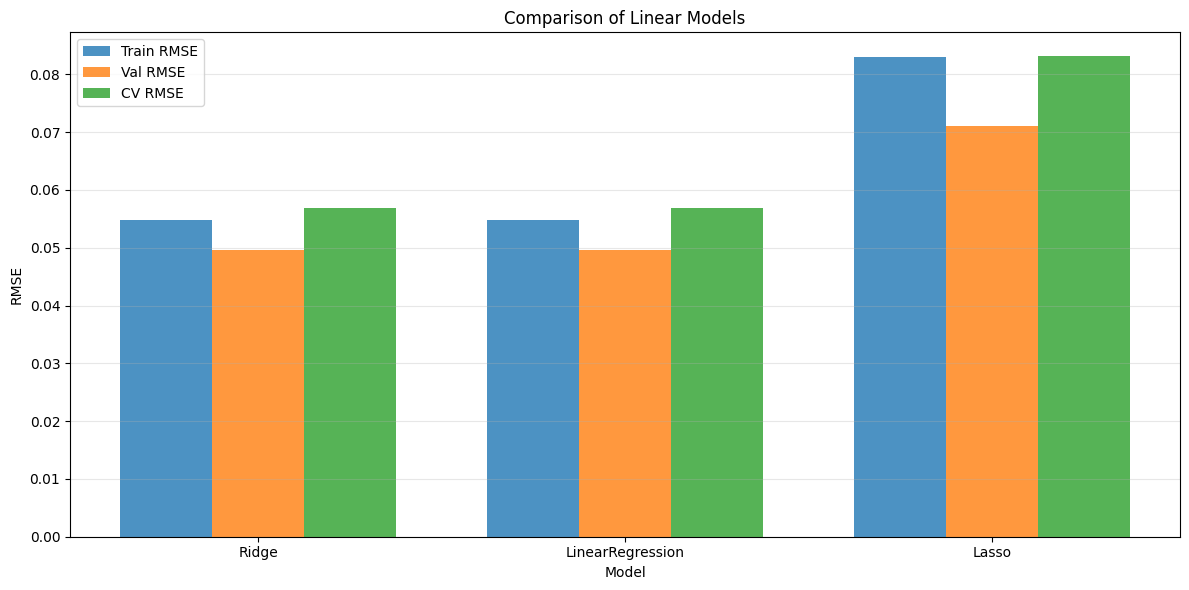

In [10]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

results = {'Model': [], 'Train RMSE': [], 'Val RMSE': [], 'CV RMSE': []}

print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")

for name, model in models.items():
    # Fit
    model.fit(X_train_prep, y_train_split)
    
    # Predictions
    train_pred = model.predict(X_train_prep)
    val_pred = model.predict(X_val_prep)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_split, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    # Cross-validation
    cv_scores = cross_val_score(
        model, X_train_prep, y_train_split,
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    results['Model'].append(name)
    results['Train RMSE'].append(train_rmse)
    results['Val RMSE'].append(val_rmse)
    results['CV RMSE'].append(cv_rmse)
    
    print(f"{name:20s} | Train: {train_rmse:.6f} | Val: {val_rmse:.6f} | CV: {cv_rmse:.6f}")

results_df = pd.DataFrame(results).sort_values('Val RMSE')
print(f"\n{results_df.to_string(index=False)}")

# Graphique comparatif
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.25

plt.bar(x - width, results_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
plt.bar(x, results_df['Val RMSE'], width, label='Val RMSE', alpha=0.8)
plt.bar(x + width, results_df['CV RMSE'], width, label='CV RMSE', alpha=0.8)

plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Comparison of Linear Models')
plt.xticks(x, results_df['Model'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Créer un meilleur graphique pour comparer les modèles
plt.figure(figsize=(15, 7))

# Trier les résultats par RMSE de validation
sorted_indices = np.argsort(results['val_rmse'])
model_names = np.array(results['model_names'])[sorted_indices]
train_rmse = np.array(results['train_rmse'])[sorted_indices]
val_rmse = np.array(results['val_rmse'])[sorted_indices]

# Créer les points et les lignes
plt.plot(model_names, train_rmse, 'bo-', label='Train RMSE', markersize=8)
plt.plot(model_names, val_rmse, 'ro-', label='Validation RMSE', markersize=8)

# Ajout des valeurs RMSE au-dessus des points
for i, (train, val) in enumerate(zip(train_rmse, val_rmse)):
    plt.text(i, train, f'{train:.4f}', ha='center', va='bottom')
    plt.text(i, val, f'{val:.4f}', ha='center', va='top')

# Personnalisation du graphique
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Modèles')
plt.ylabel('RMSE')
plt.title('Comparaison des performances des modèles (triés par RMSE de validation)')
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.legend(loc='upper left')

# Ajuster les marges
plt.tight_layout()

# Ajouter une marge en haut pour les annotations
plt.margins(y=0.2)

plt.show()

# Afficher aussi un tableau avec les différences relatives par rapport au baseline
baseline_val_rmse = results_df[results_df['Model'] == 'Linear Regression']['Validation RMSE'].values[0]
results_df['Amélioration (%)'] = ((baseline_val_rmse - results_df['Validation RMSE']) / baseline_val_rmse * 100)
print("\nComparaison avec le baseline (Linear Regression):")
print(results_df.sort_values('Validation RMSE')[['Model', 'Validation RMSE', 'Amélioration (%)']])

KeyError: 'val_rmse'

<Figure size 1500x700 with 0 Axes>

### Commentaires
On voit que le Ridge apporte une amélioration sur le modele de base seulement à partir d'un Alpha supérieur à 1. le meilleur modèle se trouve entre le Ridge à alpha = 500 et alpha = 1000.

On voit que le RMSE passe de 0.0795 (baseline model) à 0.07895 (meilleur modele), c'est quand même tres faible
- Pq amélioration si faible ?
    - preprocessing déjà très bon / peu de feature redondantes / alpha testés pas dans la bonne range 

## 3. Hyperparamter tuning
On veut trouver le meilleur alpha, on a vu a la main ce que ca donnait maintenant on va passer à de l'automatisation via la cross-validation.


HYPERPARAMETER TUNING: Ridge
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best alpha: 0.1
Best CV RMSE: 0.056833


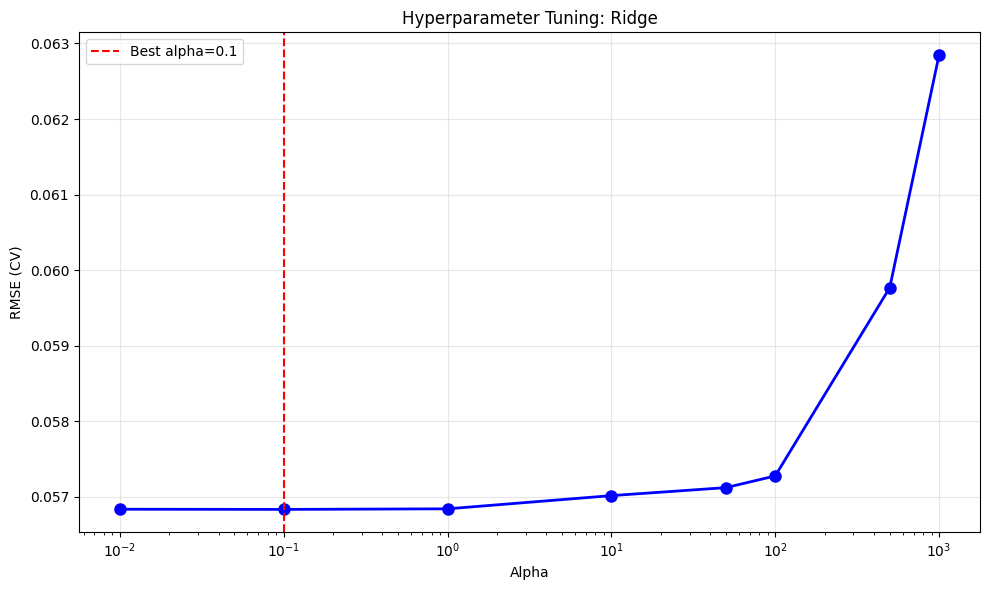

In [12]:
best_model_name = results_df.iloc[0]['Model']
print(f"\n{'='*60}")
print(f"HYPERPARAMETER TUNING: {best_model_name}")
print(f"{'='*60}")

if best_model_name == 'Ridge':
    param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}
    model = Ridge()
elif best_model_name == 'Lasso':
    param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
    model = Lasso(max_iter=10000)
else:
    param_grid = {}
    model = LinearRegression()

if param_grid:
    grid_search = GridSearchCV(
        model, param_grid,
        cv=5, scoring='neg_mean_squared_error',
        n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train_prep, y_train_split)
    
    best_alpha = grid_search.best_params_['alpha']
    best_cv_rmse = np.sqrt(-grid_search.best_score_)
    best_model = grid_search.best_estimator_
    
    print(f"\nBest alpha: {best_alpha}")
    print(f"Best CV RMSE: {best_cv_rmse:.6f}")
    
    # Graphique alpha vs RMSE
    cv_results = pd.DataFrame(grid_search.cv_results_)
    cv_results['mean_rmse'] = np.sqrt(-cv_results['mean_test_score'])
    
    plt.figure(figsize=(10, 6))
    alphas = cv_results['param_alpha'].astype(float)
    plt.plot(alphas, cv_results['mean_rmse'], 'bo-', linewidth=2, markersize=8)
    plt.axvline(x=best_alpha, color='r', linestyle='--', label=f'Best alpha={best_alpha}')
    plt.xlabel('Alpha')
    plt.ylabel('RMSE (CV)')
    plt.title(f'Hyperparameter Tuning: {best_model_name}')
    plt.xscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    best_model = model
    best_model.fit(X_train_prep, y_train_split)

## 5. Evaluation finale sur Test set


FINAL EVALUATION
Train RMSE: 0.054810
Val RMSE:   0.049684
Test RMSE:  0.055288


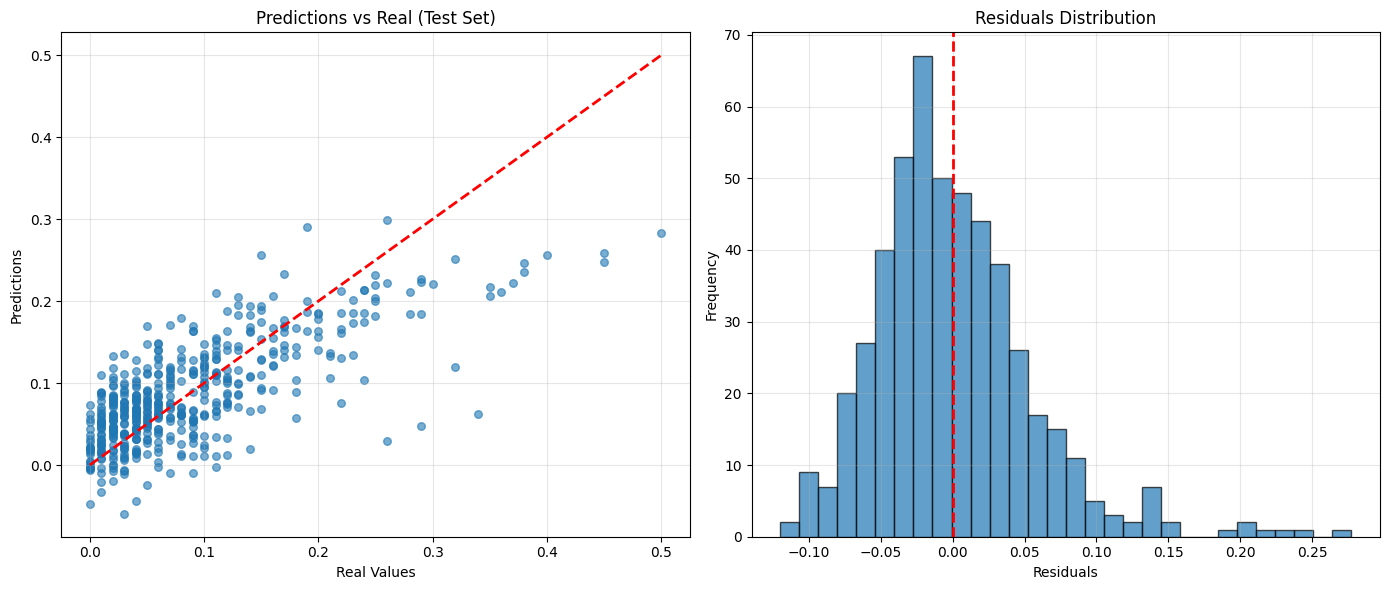

In [13]:
best_model.fit(X_train_prep, y_train_split)
y_test_pred = best_model.predict(X_test_prep)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n{'='*60}")
print("FINAL EVALUATION")
print(f"{'='*60}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_split, best_model.predict(X_train_prep))):.6f}")
print(f"Val RMSE:   {np.sqrt(mean_squared_error(y_val, best_model.predict(X_val_prep))):.6f}")
print(f"Test RMSE:  {test_rmse:.6f}")

# Graphiques de diagnostic
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predictions vs Real
axes[0].scatter(y_test, y_test_pred, alpha=0.6, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Real Values')
axes[0].set_ylabel('Predictions')
axes[0].set_title('Predictions vs Real (Test Set)')
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Commentaire 

## 6. Prédictions sur unlabaled


✓ Features match perfectly

UNLABELED PREDICTIONS
Count:  500
Mean:   0.084168
Std:    0.062761
Min:    -0.036274
Max:    0.369010


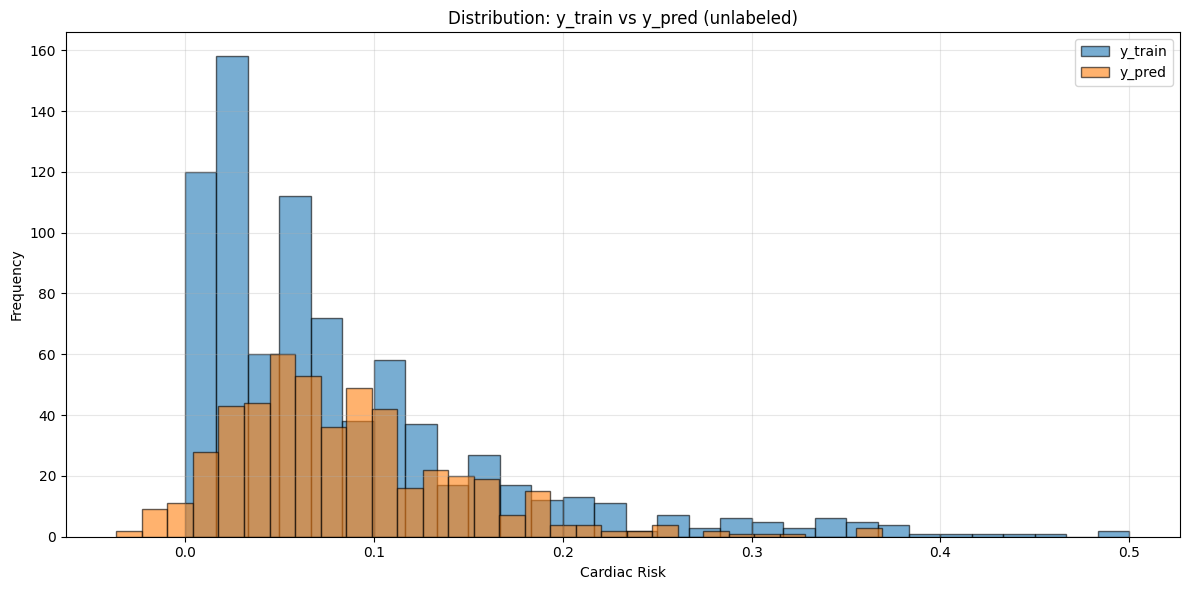

In [14]:
X_unlabeled_prep, _ = preprocess_data(X_unlabeled, scaler=scaler, fit_scaler=False)

# Vérification colonnes
if list(X_unlabeled_prep.columns) == list(X_train_prep.columns):
    print("\n✓ Features match perfectly")
else:
    print("\n✗ Features mismatch!")
    print(f"Missing: {set(X_train_prep.columns) - set(X_unlabeled_prep.columns)}")

y_pred_unlabeled = best_model.predict(X_unlabeled_prep)

print(f"\n{'='*60}")
print("UNLABELED PREDICTIONS")
print(f"{'='*60}")
print(f"Count:  {len(y_pred_unlabeled)}")
print(f"Mean:   {y_pred_unlabeled.mean():.6f}")
print(f"Std:    {y_pred_unlabeled.std():.6f}")
print(f"Min:    {y_pred_unlabeled.min():.6f}")
print(f"Max:    {y_pred_unlabeled.max():.6f}")

# Distribution comparison
plt.figure(figsize=(12, 6))
plt.hist(y_train_split, bins=30, alpha=0.6, label='y_train', edgecolor='black')
plt.hist(y_pred_unlabeled, bins=30, alpha=0.6, label='y_pred', edgecolor='black')
plt.xlabel('Cardiac Risk')
plt.ylabel('Frequency')
plt.title('Distribution: y_train vs y_pred (unlabeled)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Export

In [15]:
output_path = '../results/predictions/y_pred.csv'
np.savetxt(output_path, y_pred_unlabeled, fmt='%.6f')
print(f"\n✓ File saved: {output_path}")

# Verification
with open(output_path, 'r') as f:
    lines = f.readlines()
    print(f"Lines: {len(lines)} (expected: {len(X_unlabeled)})")
    print(f"First line: {lines[0].strip()}")
    print(f"Last line: {lines[-1].strip()}")

print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"Best model: {best_model}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Predictions: {len(y_pred_unlabeled)}")
print(f"Output: {output_path}")
print(f"{'='*60}")


✓ File saved: ../results/predictions/y_pred.csv
Lines: 500 (expected: 500)
First line: -0.006938
Last line: 0.088665

SUMMARY
Best model: Ridge(alpha=0.1)
Test RMSE: 0.055288
Predictions: 500
Output: ../results/predictions/y_pred.csv
